# Das Fadenpendel ohne Kleinwinkelnäherung [MUSTERLÖSUNG]

<div style = "background-color: LightBlue; padding: 15px; border-radius: 8px;">
<p> Diese Aufgabe kann durch einen Abstecher (Detour) in das eulersche Polygonzugverfahren nach Belieben erweitert werden. Falls dazu kein Bedarf besteht können die Blöcke der Detour einzeln durch Auswahl und das doppelte Drücken der <i>d</i>-Taste gelöscht werden. Alternativ kann die Detour als freiwillige Aufgabe im Notebook verbleiben.

**Ausgabedatum:** 02.11.2022 <br>
**Abgabedautm:** 09.11.2022 <br>
Für Rückfragen zum Übungsbetrieb wenden Sie sich an: mustermann@uni-muster.de

Das Ziel der folgenden Aufgabe ist es mittels eines Algorithmus zur numerischen Lösung von Differentialgleichungen die Unterschiede zwischen der Lösung der allgemeinen und der linearisierten DGL des Fadenpendels darzustellen und zu untersuchen. 

**Python Grundlagen:** Einfache Schleifen, Plots. <br>
**Math. Grundlagen:** Gewöhnliche Differentialgleichungen

#### I. Lösungsansätze

Wir betrachten ein Fadenpendel mit Fadenlänge $l = 1 \ \mathrm{m}$, welches um einen zunächst allgemeinen Winkel $\varphi_0$ ausgelenkt und im Anschluss losgelassen wird. Die Geschwindigkeit des Pendels zum Zeitpunkt des Loslassens sei null. Effekte durch Luftreibung, räumliche Ausdehnung des Pendelkörpers und Masse des Fadens werden vernachlässigt.

Die Bewegungsgleichung der Pendelauslenkung $\varphi(t)$ ist dann gegeben durch

$$ \ddot{\varphi}(t) + \omega^2 \sin \left[ \varphi(t) \right] = 0 \ .$$

Für sehr kleine Anfangsauslenkungen $\varphi_0 \ll 1 \ (\Rightarrow \varphi(t) \ll 1 \ \forall t)$  vereinfacht sich die Bewegungsgleichung mit Hilfe der Kleinwinkelnäherung *(KWN)* $\sin(\varphi) \approx \varphi$ zu

$$ \ddot{\varphi}(t) + \omega^2\varphi (t) = 0 \ .$$

Der Spezialfall $\varphi(0) = \varphi_0$, $\dot{\varphi}(0) = 0$ besitzt dann die analytische Lösung

$$ \varphi (t) = \varphi_0 \mathrm{cos}(\omega t) .$$

- Weisen Sie den Variablen $g$, $l$, $\omega$ ihre entsprechende Zahlenwerte in SI-Einheiten zu.
> **Hinweis:** Mittels der Eingabe von `\omega` und dem Drücken der Tab-Taste lässt sich der Buchstabe $\omega$ auch im Code schreiben. Gleiches gilt auch für alle weiteren Buchstaben des griechischen Alphabets. Dies ist jedoch nur in der Umgebung von Jupyter möglich und wird nicht in jedem Browser korrekt wiedergegeben. 

In [1]:
import numpy as np
pi = np.pi
g, l = 9.81, 1
omega = np.sqrt(g / l)

- Definieren Sie eine Funktion $\varphi_{\mathrm{KWN}} (t, \varphi_0)$, welche einen Zeitparameter $t$ sowie eine Anfangsauslenkung $\varphi_0$ entgegennimmt und die Auslenkung des oben beschriebenen Pendels in der Kleinwinkelnäherung zum Zeitpunkt $t$ ausgibt.

In [2]:
def phi_KWN(t, phi_0):
    return phi_0 * np.cos(omega*t)

Die Python-Bibliothek *scipy* ermöglicht es bei gegebenen Anfangsbedingungen Differentialgleichungen mit hoher Präzision numerisch zu lösen. Im unten gegebenen Codesegment wird eine Funktion $\varphi_{\mathrm{num}}(t, \varphi_0, n)$ definiert, welche drei Argumente entgegennimmt:
- Zeitintervall (Array oder Liste) innerhalb welches die DGL gelöst werden soll $(t)$,
- Anfangsauslenkung des Pendels $(\varphi_0)$,
- Ordnung bis zu welcher die Reihentwicklung des Sinus zur Lösung verwendet wird $(n)$. Der Wert $n = 0$ entspricht der Kleinwinkelnäherung und bei Eingabe von `n = "ex"` wird die allgemeine DGL gelöst.

Innerhalb dieser Funktion wird die Bewegungsgleichung mittels *scipy.odeint* (basierend auf dem Runge-Kutta-Verfahren[^1]) gelöst und ein Array ausgegeben, welches die Pendelauslenkungen zum vorher eingegebenen Zeitintervall enthält. Um die nachfolgenden Aufgaben zu lösen ist es **nicht** nötig den Code hinter dieser Funktion nachzuvollziehen, jedoch schadet es nicht sich einen groben Überblick zu verschaffen.

[^1]: https://www.lernhelfer.de/schuelerlexikon/mathematik-abitur/artikel/das-runge-kutta-verfahren#

In [4]:
from scipy.integrate import odeint
def phi_num(t, phi_0, n = "ex"): 
    # Wird n nicht spezifiziert, soll die exakte DGL gelöst werden. 
    def f(y, t): # f definiert die rechte Seite der DGL: dy/dt = f(y, t)                 
        if n == "ex":        
            return [y[1], -omega**2*np.sin(y[0])] 
            # Da es sich um eine DGL 2.Ordnung handelt muss neben y(t) auch die Ableitung y'(t) 
            # mitgelöst werden. Hier bezeichnet y[i] die i-te Ableitung
        else:
            s = 0
            for i in range(0, n + 1): # range(0,0) führt keine Iteration durch darum "+1"   
                s = s + ((-1)**i * y[0]**(2*i+1) / np.math.factorial(2*i+1))
            return [y[1], -omega**2*s]
    x_init = [phi_0, 0] # Anfangsbedingungen [y(t=0), dy/dt(t=0)]     
    x = (odeint(f, x_init, t).T)[0] # Lösung der DGL durch die Routine odeint
    return x

- Überprüfen Sie zunächst, dass die numerische Lösung zur linearisierten DGL (Kleinwinkelnäherung) mit der analytischen Lösung übereinstimmt. Die Anfangsauslenkung kann beliebig gewählt werden. Wie groß ist der relative Fehler nach $10$, $100$, $1000$ Perioden?

In [15]:
T = 2*pi/omega; phi_0 = pi/4
N = [10, 100, 1000]
for k in N:
    t_val = np.arange(0, (k + 1)*T, T)
    error = abs((phi_KWN(t_val[-1], phi_0) - phi_num(t_val, phi_0, n = 0)[-1]) / phi_KWN(t_val[-1], phi_0))
    print("Relativer Fehler nach %s Perioden: %s %%" %(k, round(error * 100, 5)))

Relativer Fehler nach 10 Perioden: 1e-05 %
Relativer Fehler nach 100 Perioden: 0.00022 %
Relativer Fehler nach 1000 Perioden: 0.00252 %


##### I.I. Detour: Ein simpler, iterativer Ansatz

<div style = "background-color: LightBlue; padding: 15px; border-radius: 8px;"> In dieser Detour lernen die Studierenden ein simples, iteratives Lösungsverfahren für Differentialgleichungen kennen, welches auch als <b>eulersches Polygonzugverfahren</b> bekannt ist. Auch wenn dieses Verfahren weder sehr präzise, noch effektiv ist, lassen sich über ihn die Grundzüge von numerischen Lösungsverfahren anschaulich vermitteln.

In der vorherigen Aufgabe ist klar geworden wie präzise und effektiv die Implementierung des Runge-Kutta-Verfahrens sein kann. Bevor wir unser Augenmerk auf die Lösung der allgemeinen Differentialgleichung legen macht es Sinn ebenfalls über einfachere, wenn auch weniger präzise Lösungsmethoden zu sprechen. Anhand des **eulerschen Polygonzugverfahrens** lassen sich die Grundzüge von numerischen Lösungsverfahren gut näherbringen. Im Folgenden wollen wir alle auftretenden Größen als **dimensionslos** annehmen.

<img align="right" src="Iterativ_1.PNG" width="300" height="200">
Betrachten Sie hierzu zunächst die gewöhnliche Differentialgleichung

$$\frac{\mathrm{d}y}{\mathrm{d}t} \equiv \dot{y}(t) = ay(t) \ , $$

welche für die Anfangsbedingung $y(t=0)=y_0$ die analytische Lösung $y(t) = y_0 \exp (at)$ besitzt. Eine solche DGL findet sich bspw. auch beim radioaktiven Zerfall wieder. Soll die Differentialgleichung in einem festen Zeitintervall $[0, t_{\mathrm{max}}]$ gelöst werden so kann die Lösung auch approximiert werden indem man möglichst kleine Zeitschritte $\Delta t$ wählt und dadurch eine diskrete Menge an Zeitpunkten als Zeitintervall erhält: $\{0, \Delta t, 2\Delta t, \dots, n\Delta t = t_{\mathrm{max}} \}$. Damit gilt dann 

$$ \frac{\Delta y}{\Delta t} = \frac{y(0 + \Delta t) - y(0)}{\Delta t} \approx \dot{y}(0) = ay(0) = ay_0 \ .$$

Je kleiner die Zeitschritte gewählt werden, desto kleiner wird der Fehler durch die Näherung. Einfaches Umformen liefert letztendlich den zentralen Zusammenhang

\begin{equation}
    y(\Delta t) = y(0) + ay_0\Delta t = y_0(1 + a\Delta t) \ ,
\end{equation}

welcher bereits das zweite Paar an Koordinaten liefert (neben den Anfangsbedingungen). Dieses Schema kann weitervefolgt werden, bis alle Zeitpunkte im Intervall einen $y$-Wert erhalten haben, wie in der Grafik oben rechts dargestellt ist.

- Probieren Sie sich zunächst an der Implementierung des obigen Beispiels. Die Konstanten $a, \ y_0$, sowie das Zeitfenster können beliebig gewählt werden. Achten Sie jedoch darauf ausreichend kleine Zeitschritte $\Delta t$ zu verwenden. Vergleichen Sie Ihre Lösung mit der analytischen Lösung in einem Plot und achten Sie auf eine sinnvolle Darstellung.

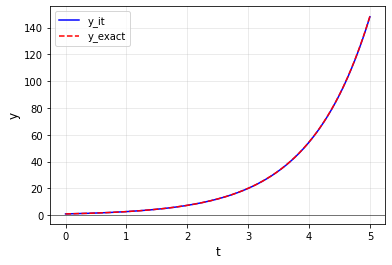

In [17]:
import matplotlib.pyplot as plt

def y_it(t, a, y_0):
    Dt = t[1] - t[0]
    y = np.zeros(len(t)); y[0] = y_0
    for i in range(1, len(t)):
        y[i] = y[i-1] * (1 + a*Dt)
    return y

def y_exact(t, a, y_0):
    return y_0 * np.exp(a*t)

Dt = 0.001
a, y_0 = 1, 1
t_val = np.arange(0, 5 + Dt, Dt)

plt.plot(t_val, y_it(t_val, a, y_0), color = "blue", label = "y_it")
plt.plot(t_val, y_exact(t_val, a, y_0), linestyle = '--', color = "red", label = "y_exact") 
plt.xlabel("t", fontsize = 12); plt.ylabel("y", fontsize = 12)
plt.grid(which = "major", alpha = 0.3)
plt.axhline(0, color = "black", linewidth = 1, alpha = 0.5)
plt.legend()
plt.show()

Möchte man Differentialgleichungen zweiter Ordnung lösen wird das iterative Lösungsverfahren jedoch etwas komplizierter. Betrachten Sie als Beispiel $\ddot{y}(t) = a^2y(t)$ mit $y(0) = y_0$, $\dot{y}(0) = 0$. Die analytische Lösung ist gegeben durch

$$y(t) = \frac{y_0}{2}\left(\mathrm{e}^{at} + \mathrm{e}^{-at}\right) = y_0 \cosh (at) \ .$$

Die Differentialgleichung zweiter Ordnung muss für unseren Ansatz zunächst umgeschrieben werden, sodass sie eine Funktion enthält die maximal einmal differenziert wird:

$$ \ddot{y}(t) = \frac{\mathrm{d}}{\mathrm{d}t}\dot{y}(t) = a^2y(t) \ . $$

An dieser Stelle kann wieder das Verfahren benutzt werden, welches im vorigen Abschnitt diskutiert wurde.

$$ \frac{\Delta \dot{y}}{\Delta t} = \frac{\dot{y}(0 + \Delta t) - \dot{y}(0)}{\Delta t} \approx \ddot{y}(0) = a^2y(0) = a^2y_0 \ .$$

Mit den gegebenen Anfangsbedingungen bezüglich der ersten Zeitableitung sind uns auch hier nun zwei Koordinatenpunkte für $\dot{y}$ bekannt: $(0, 0)$ und $(\dot{y}(\Delta t) = a^2y_0\Delta t, \Delta t)$. Die ersten beiden Koordinatenpunkte für $y(t)$ selbst ergeben sich direkt aus den Anfangsbedingungen:

$$ \frac{y(\Delta t) - y(0)}{\Delta t} \approx \dot{y}(0) = 0 \quad \Leftrightarrow \quad y(\Delta t) = y(0) = y_0 \ .$$

Es ist nun wichtig zu verstehen, dass die iterative Lösung von $y$ mit der iterativen Lösung von $\dot{y}$ zusammenhängt und beide Funktionen somit gleichzeitig ermittelt werden müssen. Dieses Verfahren ist schematisch nochmal im unteren Schaubild dargestellt.


<img align="center" src="Iterativ_2.PNG" width="600" height="500">

- Verwenden Sie den oben diskutierten Algorithmus um die linearisierte Differentialgleichung des Fadenpendels (nun sind alle Größen wieder dimensionsbehaftet!)

    $$ \ddot{\varphi}(t) + \omega^2 \varphi (t) = 0 $$

  für beliebige Anfangsauslenkungen iterativ zu lösen. Stellen Sie sowohl die iterative, als auch die analytische Lösung (beliebiges $\varphi_0$) über mehrere Perioden (5-10) zusammen in einem Plot dar und variieren Sie die Zeitschritte $\Delta t$. Wie verhält sich der Fehler auf die iterative Lösung? Wie verhält sich die Länge der Rechenzeit? Verwenden Sie für die Plots eine dimensionslose Zeitskala, indem Sie die Zeitwerte auf die Periodendauer der KWN-Lösung $(T_{\mathrm{KWN}} = 2\pi\sqrt{l/g})$ normieren, also $x := t/T_{\mathrm{KWN}}$.

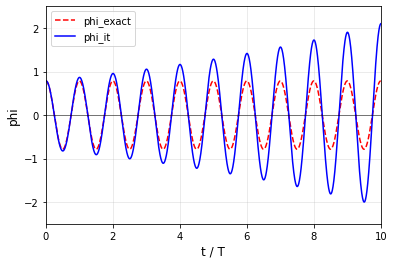

Der Fehler wächst mit der Zeit, wodurch die iterative Lösung nur für kurze Zeitintervalle um die Anfangsbedingung akkurat ist! Eine feinere Wahl für Delta_t erhöht die akkurate Zeitspanne, führt jedoch auch zu längeren Rechenzeiten bei der Ausführung des Programms.


In [18]:
def phi_KWN_it(t, ϕ_0):
    Dt = t[1] - t[0]
    phi_val = np.zeros(len(t)); phi_val[0] = phi_0
    phid_val = np.zeros(len(t))
    for i in range(1, len(t)):
        phi_val[i] = phi_val[i-1] + phid_val[i-1] * Dt
        phid_val[i] = phid_val[i-1] - omega**2 * phi_val[i-1] * Dt   
    return phi_val

Dt = 0.01
t = np.arange(0, 10*T, Dt)
x = t / T

plt.plot(x, phi_KWN(t, phi_0), label = "phi_exact", color = "red", linestyle = "--")
plt.plot(x, phi_KWN_it(t, phi_0), label = "phi_it", color = "blue")
plt.xlabel("t / T", fontsize = 12); plt.ylabel("phi", fontsize = 12)
plt.axis([0, 10, -2.5, 2.5])
plt.grid(which = "major", alpha = 0.3)
plt.axhline(0, color = "black", linewidth = 1, alpha = 0.5)
plt.legend()
plt.show()

print("Der Fehler wächst mit der Zeit, wodurch die iterative Lösung nur für kurze Zeitintervalle um die Anfangsbedingung " 
      "akkurat ist! Eine feinere Wahl für Delta_t erhöht die akkurate Zeitspanne, führt jedoch auch zu längeren Rechenzeiten "
      "bei der Ausführung des Programms.")

- Definieren Sie zuletzt eine Funktion $\varphi_{\mathrm{it}}(t, \varphi_0)$, welche einen Array $t$ mit äquidistanten Zeitpunkten sowie eine Anfangsauslenkung $\varphi_0$ entgegennimmt und die Auslenkung des allgemeinen Fadenpendels (ohne KWN) zu allen Zeitpunkten in $t$ ausgibt.

In [19]:
def phi_it(t, phi_0):
    Dt = t[1] - t[0]
    phi_val = np.zeros(len(t)); phi_val[0] = phi_0
    phid_val = np.zeros(len(t))
    for i in range(1, len(t)):
        phi_val[i] = phi_val[i-1] + phid_val[i-1] * Dt
        phid_val[i] = phid_val[i-1] - omega**2 * np.sin(phi_val[i-1]) * Dt
    return phi_val

#### II. Vergleich zwischen KWN und allgemeiner Lösung

- Überlegen Sie sich nun ein Zeitintervall $[0, t_{\max}]$ in Form eines Arrays in dem Sie die Lösung von sowohl der allgemeinen, als auch der approximierten DGL untersuchen wollen. Stellen Sie beide Lösungen zusammen in einem Graphen dar, einmal für die Anfangsauslenkung $\varphi_0 = 0.1°$ und einmal für $\varphi_0 = 60°$. Achten Sie auf Achsenbeschriftungen und eine sinnvolle Formatierung. Verwenden Sie außerdem eine dimensionslose Zeitskala für die x-Achse mit $x := t/T_{\mathrm{KWN}}$, wobei $T_{\mathrm{KWN}}$ die Periodendauer der KWN-Lösung bezeichnet.

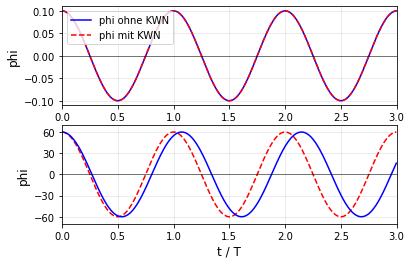

In [20]:
import matplotlib.pyplot as plt
phi_0 = np.array([0.1, 60]) * (2*pi)/360 #Umrechnung in rad
t_val = np.arange(0, 3*T, 0.01) #3 Perioden
x_val = t_val / T

fig, (ax1, ax2) = plt.subplots(2)

ax1.plot(x_val, phi_num(t_val, phi_0[0]) * 180/pi, color = "blue", label = "phi ohne KWN")
ax1.plot(x_val, phi_KWN(t_val, phi_0[0]) * 180/pi, color = "red", linestyle = "--", label = "phi mit KWN")
ax1.axis([0, 3, -0.11, 0.11])
ax1.set_ylabel("phi", fontsize = 12)
ax1.set_yticks([-0.1, -0.05, 0, 0.05, 0.1])
ax1.grid(which = "major", alpha = 0.3)
ax1.axhline(0, color = "black", linewidth = 1, alpha = 0.5)
ax1.legend(loc = 2)

ax2.plot(x_val, phi_KWN(t_val, phi_0[1]) * 180/pi, label = "phi mit KWN", color = "red", linestyle = "--")
ax2.plot(x_val, phi_num(t_val, phi_0[1]) * 180/pi, label = "phi ohne KWN", color = "blue")
ax2.axis([0, 3, -70, 70])
ax2.set_xlabel("t / T", fontsize = 12); ax2.set_ylabel("phi", fontsize = 12)
ax2.set_yticks([-60, -30, 0, 30, 60])
ax2.grid(which = "major", alpha = 0.3)
ax2.axhline(0, color = "black", linewidth = 1, alpha = 0.5)

plt.show()

- Wie klar zu erkennen ist, schwingt das "reale" Fadenpendel bei höheren Anfangsauslenkungen mit einer niedrigeren Frequenz als bei kleinen Anfangsauslenkungen. Diese Frequenz, als Funktion der Anfangsauslenkung $\varphi_0$, soll nun bestimmt werden. Dazu betrachten wir wieder die numerische Lösung und machen uns klar, dass die Zeit zwischen einem Maximum und einem Minimum gerade die halbe Periodendauer $T/2$ ist. Schreiben Sie einen Algorithmus, der die zeitliche Position des ersten Minimums in der numerischen Lösung ermittelt und daraus die tatsächliche Frequenz $f_\mathrm{exakt}$ bestimmt. Plotten Sie anschließend die **normierte** Frequenz gegen die Anfangsauslenkungen im Intervall $[\epsilon, \pi/2]$, wobei $\epsilon$ beliebig sein darf mit $0 < \epsilon \ll 1$.

> **Hinweis:** Achten Sie auf Effizienz beim Schreiben Ihres Codes. Die Funktion $\varphi_{\mathrm{num}}$ sollte so selten wie möglich aufgerufen werden, damit die Laufzeit des Programms nicht mehrere Minuten beträgt!

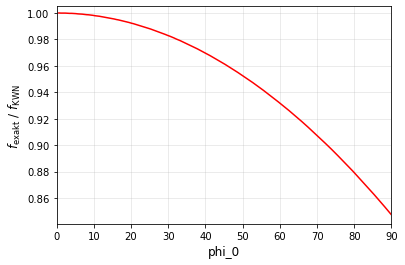

In [21]:
def f_exact(phi_0):
    Dt = 1e-4
    t_val = np.arange(0, T, Dt)
    phi_val = phi_num(t_val, phi_0)
    T_half = 0
    for i in range(1, len(t_val)):
        d = phi_val[i+1] - phi_val[i]
        if d >= 0:
            T_half = i * Dt
            break
    return 1/(2*T_half)

'''Alternativ:
def f_exact(phi_0):
    Dt = 1e-4
    t_val = np.arange(0, 1.5, Dt)
    phi_val = phi_num(t_val, phi_0)
    T_half = Dt * np.argmin(phi_val)
    return 1/(2*T_half) '''
    

eps = 0.01
phi_0_val = np.arange(eps, pi/2 + eps, eps)
f_val = np.zeros(len(phi_0_val))
for i in range(0, len(phi_0_val)):
    f_val[i] = f_exact(phi_0_val[i])
y_val = f_val * T

plt.plot(phi_0_val * 180/pi, y_val, color = "red")
plt.xlabel("phi_0", fontsize = 12); plt.ylabel("$f_\mathrm{exakt}$ / $f_\mathrm{KWN}$", fontsize = 12)
plt.axis([0, 90, y_val[-1] - 5e-3, y_val[0] + 5e-3])
plt.grid(which = "major", alpha = 0.3)
plt.show()

- Unser Vorgehen im vorherigen Aufgabenteil setzte voraus, dass es sich bei der numerischen, exakten Lösung auch tatsächlich um eine periodische Funktion handelt. Überprüfen Sie dies mithilfe der gefundenen Periodendauern!

In [28]:
#Für sehr kleine phi_0 ist die Lösung periodisch (Kleinwinkelnäherung), sollte die Lösung auch für phi_0 = pi/2 periodisch sein so
#lässt sich annehmen dass sie auch für alle Werte zwischen 0 und pi/2 periodisch ist.

T = 1 / f_exact(pi/2)
t_val = np.arange(0, 1000*T, T)
phi_val = phi_num(t_val, pi/2)
print("Durchschnitt. Auslenkung an Hochpunkten (nach 1000 Perioden): %s rad = pi/2" %round(np.mean(phi_val), 4))
print("Standardabweichung: %s rad" %np.format_float_scientific(np.std(phi_val), 2))

Durchschnitt. Auslenkung an Hochpunkten (nach 1000 Perioden): 1.5691 rad = pi/2
Standardabweichung: 1.3e-03 rad


Mittels ```np.polyfit(x, y, n)``` lässt sich eine ganzrationale Funktion 

$$ y(x) = \sum_{k=0}^n a_kx^k $$

an einen Datensatz $(x,y)$ fitten. Dieser Funktion muss jedoch auch der Grad $n$ des Polynoms übergeben werden. 

> Ein **Fit** bezeichnet eine mathematische Funktion $f$ dessen Parameter so gewählt werden, dass die Funktion einen gegebenen Datensatz möglichst gut beschreibt.

- Benutzen Sie *polyfit* um eine geeignete mathematische Funktion zu finden die $f_{\mathrm{exact}}(\varphi_0)$ beschreibt. Geben Sie die Koeffizienten $a_k$ aus und überprüfen Sie die Qualität des Fits. Was ist der physikalische Definitionsbereich von $f_{\mathrm{exact}}(\varphi_0)$?

In [29]:
param = np.polyfit(phi_0_val, f_val, 2)
print("f_exact(phi_0) = a*phi_0^2 + b*phi_0 + c")
print("a = ", np.format_float_scientific(param[0], 2), "s^-1 rad^-2")
print("b = ", np.format_float_scientific(param[1], 2), "s^-1 rad^-1")
print("c = ", round(param[2], 2), "s^-1")

def fit(phi_0):
    return param[0]*phi_0**2 + param[1]*phi_0 + param[2]

diff = abs(f_val - fit(phi_0_val))
print("Max diff between fit and f_exact: ", np.format_float_scientific(np.max(diff), 2), "Hz")

f_exact(phi_0) = a*phi_0^2 + b*phi_0 + c
a =  -3.07e-02 s^-1 rad^-2
b =  -3.94e-04 s^-1 rad^-1
c =  0.5 s^-1
Max diff between fit and f_exact:  6.89e-05 Hz


Analytisch findet sich für die Frequenz des Fadenpendels ohne KWN der folgende Ausdruck:
$$ f_{\mathrm{exact}}(\varphi_0) = f_{\mathrm{KWN}} \left( 1 - \frac{1}{4}\left( \frac{\varphi_0}{2} \right)^2 + \mathcal{O}\left[ \left( \frac{\varphi_0}{2} \right)^4 \right] \right) \ .$$
 - Vernachlässigen Sie alle Terme höherer Ordnungen ($\varphi_0^4$ und größer) und vergleichen Sie Ihre gefundenen Koeffizienten mit der analytischen Lösung!

In [30]:
a = -omega/(32*pi)
c = omega/(2*pi)

print("Analytische Lösung: ")
print("a = ", np.format_float_scientific(a, 2), "s^-1 rad^-2")
print("b =  0 s^-1 rad^-1")
print("c = ", round(c, 2), "s^-1")

Analytische Lösung: 
a =  -3.12e-02 s^-1 rad^-2
b =  0 s^-1 rad^-1
c =  0.5 s^-1
